# 05 — BERTopic Topic Modeling on BIS Central Bank Speeches

This notebook extends the classical topic modeling pipeline developed in the previous notebooks:

1. **Notebook 01**: exploratory data analysis.
2. **Notebook 02**: preprocessing with two text representations:
   - `clean_text` for TF-IDF/NMF and LDA,
   - `bertopic_text` for embedding-based BERTopic.
3. **Notebook 03**: TF-IDF + NMF.
4. **Notebook 04**: CountVectorizer + LDA.

The goal here is to estimate a **modern embedding-based topic model** with BERTopic and compare its results with the classical NMF and LDA baselines.

Methodological idea:

- NMF and LDA are based on bag-of-words representations.
- BERTopic uses sentence embeddings to represent full speeches in a semantic vector space.
- It then clusters semantically similar speeches and represents each cluster with c-TF-IDF keywords.

This makes BERTopic useful as a robustness extension: it can capture semantic similarity beyond exact word overlap.


## 1. Setup

This cell installs the required libraries in Google Colab if needed.

BERTopic depends on:

- `sentence-transformers` for document embeddings,
- `umap-learn` for dimensionality reduction,
- `hdbscan` for clustering,
- `bertopic` for the full topic modeling pipeline.

If the packages are already installed, this cell will run quickly.


In [1]:
%%capture
!pip install -q bertopic sentence-transformers umap-learn hdbscan gensim

## 2. Imports and global settings

We import standard data-analysis libraries and the BERTopic components.

The random seed is fixed for reproducibility.


In [2]:
import os
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic import BERTopic

from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
plt.rcParams["figure.dpi"] = 120

## 3. Upload and load the preprocessed dataset

Upload the **new** `bis_speeches_preprocessed.csv` produced by Notebook 02.

This file must contain at least:

- `clean_text`: lemmatized text for classical models and coherence evaluation,
- `bertopic_text`: less aggressively cleaned text for sentence embeddings,
- `year`,
- `macro_period`,
- `central_bank`,
- `description`.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Data/bis_speeches_preprocessed_CB.csv")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,description,raw_text_stripped,clean_text,bertopic_text,central_bank,year,month,macro_period,n_words_raw,n_characters_raw,n_words_clean
0,Lecture delivered in honour of Professor Xenop...,Mr. Tietmeyer considers European monetary inte...,tietmeyer consider european monetary integrati...,Mr. Tietmeyer considers European monetary inte...,bank of greece,1997,10,Pre-GFC,5070,31212,2078
1,"Speech given by Mr Nicholas C Garganas, Deputy...",Mr Garganas gives a speech on integrating Gree...,garganas integrate greece euro area challenge ...,Mr Garganas gives a speech on integrating Gree...,bank of greece,1999,9,Pre-GFC,2307,14497,1096
2,"Speech by Mr Lucas Papademos, Governor of the ...",Lucas Papademos: The completion of the changeo...,lucas papademos completion changeover euro luc...,Lucas Papademos: The completion of the changeo...,bank of greece,2001,10,Pre-GFC,2975,18231,1213
3,"Address by Mr Nicholas C Garganas, Deputy Gove...",Nicholas Garganas: The Greek economy within th...,nicholas garganas greek economy euro area nich...,Nicholas Garganas: The Greek economy within th...,bank of greece,2002,5,Pre-GFC,2129,13387,1008
4,"Speech by Mr Nicholas C Garganas, Governor of ...",Nicholas C Garganas: The European financial ma...,nicholas garganas european financial marketpla...,Nicholas C Garganas: The European financial ma...,bank of greece,2002,10,Pre-GFC,2001,13166,982


## 4. Basic checks

Before fitting BERTopic, we verify that the required columns exist and that the dataset corresponds to the corrected preprocessing.

The protected terms check is important: if all counts are zero, it probably means that the old preprocessing file was loaded by mistake.


In [4]:
required_columns = [
    "clean_text",
    "bertopic_text",
    "year",
    "macro_period",
    "central_bank",
    "description"
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("Number of speeches:", len(df))
print("Years:", df["year"].min(), "-", df["year"].max())
print("Number of central banks:", df["central_bank"].nunique())
print("Missing clean_text:", df["clean_text"].isna().sum())
print("Missing bertopic_text:", df["bertopic_text"].isna().sum())

protected_terms = [
    "monetary_policy",
    "financial_stability",
    "price_stability",
    "interest_rate",
    "exchange_rate",
    "federal_reserve",
    "euro_area",
    "climate_change",
    "basel_iii",
    "covid19"
]

print("\nProtected terms found in clean_text:")
for term in protected_terms:
    count = df["clean_text"].fillna("").str.contains(term, regex=False).sum()
    print(f"{term}: {count} documents")

Number of speeches: 18922
Years: 1997 - 2025
Number of central banks: 118
Missing clean_text: 0
Missing bertopic_text: 0

Protected terms found in clean_text:
monetary_policy: 1 documents
financial_stability: 2 documents
price_stability: 0 documents
interest_rate: 0 documents
exchange_rate: 0 documents
federal_reserve: 0 documents
euro_area: 1 documents
climate_change: 3 documents
basel_iii: 0 documents
covid19: 1286 documents


## 5. Prepare documents for BERTopic

BERTopic will use `bertopic_text`, not `clean_text`.

Why?

- `clean_text` is heavily processed and is ideal for sparse bag-of-words models.
- `bertopic_text` keeps more natural linguistic structure, which is better for sentence embeddings.

We still remove empty texts as a safety check.


In [5]:
df_bertopic = df.copy()

df_bertopic["bertopic_text"] = df_bertopic["bertopic_text"].fillna("").astype(str)
df_bertopic["clean_text"] = df_bertopic["clean_text"].fillna("").astype(str)

df_bertopic = df_bertopic[df_bertopic["bertopic_text"].str.strip().str.len() > 0].copy()
df_bertopic = df_bertopic.reset_index(drop=True)

docs = df_bertopic["bertopic_text"].tolist()

print("Number of documents used for BERTopic:", len(docs))
print("\nExample document:")
print(docs[0][:1000])

Number of documents used for BERTopic: 18922

Example document:
Mr. Tietmeyer considers European monetary integration and its implications for the international monetary system Lecture delivered in honour of Professor Xenophon Zolotas, Honorary Governor of the Bank of Greece, by the President of the Deutsche Bundesbank, Prof. Hans Tietmeyer, in Athens on 17/10/97. I. The twentieth century does not lack for experience or lessons derived from different international monetary arrangements. Now -- just before this century comes to a close -- Europe is about to embark on a new experiment with far-reaching implications: a monetary union of nation states with a supranational central bank. Some economists see this as things coming full circle. The century began with the gold standard. It will end with a monetary union. As at the beginning of this century, at its end there will be a “denationalised” currency. Countries cannot produce this money more as they see fit. Whereas earlier this century

## 6. Define BERTopic components

BERTopic has three main components:

1. **Embedding model**: converts each speech into a dense semantic vector.
2. **UMAP**: reduces the embedding dimension before clustering.
3. **HDBSCAN**: clusters speeches and can assign noisy documents to topic `-1`.

For time reasons and computational stability, we use a compact sentence-transformer model:

`all-MiniLM-L6-v2`

This is a strong practical baseline: fast enough for Colab and good enough for semantic clustering.

The vectorizer is used only to represent topics with c-TF-IDF keywords. We use unigrams and bigrams and remove both standard and domain-specific stopwords.


In [6]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

domain_stopwords = {
    "central", "bank", "banks", "speech", "speeches",
    "speaker", "governor", "deputy", "mr", "mrs", "ms", "dr",
    "year", "years", "month", "months", "today", "tomorrow",
    "time", "times", "period", "periods", "recent", "currently",
    "also", "would", "could", "should", "may", "might", "must",
    "many", "much", "well", "like", "make", "made", "way", "ways",
    "new", "old", "good", "important", "particular", "example",
    "first", "second", "third", "finally", "however", "therefore",
    "indeed", "although", "among", "across", "within", "without",
    "report", "reports", "meeting", "meetings", "conference",
    "remarks", "address", "presentation"
}

stopwords = list(set(ENGLISH_STOP_WORDS).union(domain_stopwords))

vectorizer_model = CountVectorizer(
    stop_words=stopwords,
    ngram_range=(1, 2),
    min_df=20,
    max_features=10000
)

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=RANDOM_STATE
)

hdbscan_model = HDBSCAN(
    min_cluster_size=100,
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    language="english",
    calculate_probabilities=False,
    verbose=True
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 7. Compute embeddings

This cell computes document embeddings.

This is often the longest step. It is separated from the model fitting step so that the embeddings can be reused if needed.


In [7]:
embeddings = embedding_model.encode(
    docs,
    batch_size=32,
    show_progress_bar=True
)

print("Embeddings shape:", embeddings.shape)

Batches:   0%|          | 0/592 [00:00<?, ?it/s]

Embeddings shape: (18922, 384)


## 8. Fit BERTopic

This cell fits BERTopic on the central bank speeches.

The output is:

- `topics`: the topic assigned to each speech,
- topic `-1`: outlier/noise documents according to HDBSCAN.

Unlike NMF and LDA, BERTopic does not force every document into one of a fixed number of topics.


In [8]:
topics, _ = topic_model.fit_transform(docs, embeddings)

df_bertopic["bertopic_topic"] = topics

topic_info = topic_model.get_topic_info()

print("Number of topics including outliers:", topic_info.shape[0])
print("Number of non-outlier topics:", (topic_info["Topic"] != -1).sum())
print("Outlier share:", (df_bertopic["bertopic_topic"] == -1).mean())

topic_info.head(20)

2026-04-29 16:56:10,642 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-29 16:57:10,333 - BERTopic - Dimensionality - Completed ✓
2026-04-29 16:57:10,336 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-29 16:57:18,973 - BERTopic - Cluster - Completed ✓
2026-04-29 16:57:18,990 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-29 17:00:17,896 - BERTopic - Representation - Completed ✓


Number of topics including outliers: 39
Number of non-outlier topics: 38
Outlier share: 0.10754677095444456


,Topic,Count,Name,Representation,Representative_Docs
0,-1,2035,-1_financial_policy_market_economic,"[financial, policy, market, economic, global, ...","[Agus D W Martowardojo: Managing stability, pr..."
1,0,5582,0_euro_policy_financial_monetary,"[euro, policy, financial, monetary, area, euro...",[Daniel K Tarullo: Monetary policy and financi...
2,1,1053,1_india_financial_sector_banking,"[india, financial, sector, banking, indian, cr...",[Anand Sinha: Indian banking – journey into th...
3,2,721,2_japan_prices_percent_economic,"[japan, prices, percent, economic, firms, econ...",[Koji Ishida: Economic activity and prices in ...
4,3,637,3_malaysia_financial_finance_industry,"[malaysia, financial, finance, industry, devel...",[Zeti Akhtar Aziz: Emerging trends in Asia and...
5,4,607,4_uk_england_inflation_policy,"[uk, england, inflation, policy, financial, mp...",[Mervyn King: Twenty years of inflation target...
6,5,546,5_canada_canadian_inflation_policy,"[canada, canadian, inflation, policy, economy,...",[David Dodge: Canada’s economic performance af...
7,6,535,6_philippines_percent_financial_banking,"[philippines, percent, financial, banking, cou...",[Benjamin E Diokno: Accounting as the language...
8,7,462,7_payments_digital_payment_innovation,"[payments, digital, payment, innovation, money...",[The cost of not issuing a digital euro Speech...
9,8,450,8_riksbank_sweden_inflation_policy,"[riksbank, sweden, inflation, policy, swedish,...",[SPEECH DATE: 5 March 2018 SPEAKER: Governor o...


## 9. Inspect the largest topics

We inspect the largest topics and their c-TF-IDF keywords.

This is the BERTopic equivalent of reading the top words in NMF or LDA.


In [9]:
topic_info.head(15)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2035,-1_financial_policy_market_economic,"[financial, policy, market, economic, global, ...","[Agus D W Martowardojo: Managing stability, pr..."
1,0,5582,0_euro_policy_financial_monetary,"[euro, policy, financial, monetary, area, euro...",[Daniel K Tarullo: Monetary policy and financi...
2,1,1053,1_india_financial_sector_banking,"[india, financial, sector, banking, indian, cr...",[Anand Sinha: Indian banking – journey into th...
3,2,721,2_japan_prices_percent_economic,"[japan, prices, percent, economic, firms, econ...",[Koji Ishida: Economic activity and prices in ...
4,3,637,3_malaysia_financial_finance_industry,"[malaysia, financial, finance, industry, devel...",[Zeti Akhtar Aziz: Emerging trends in Asia and...
5,4,607,4_uk_england_inflation_policy,"[uk, england, inflation, policy, financial, mp...",[Mervyn King: Twenty years of inflation target...
6,5,546,5_canada_canadian_inflation_policy,"[canada, canadian, inflation, policy, economy,...",[David Dodge: Canada’s economic performance af...
7,6,535,6_philippines_percent_financial_banking,"[philippines, percent, financial, banking, cou...",[Benjamin E Diokno: Accounting as the language...
8,7,462,7_payments_digital_payment_innovation,"[payments, digital, payment, innovation, money...",[The cost of not issuing a digital euro Speech...
9,8,450,8_riksbank_sweden_inflation_policy,"[riksbank, sweden, inflation, policy, swedish,...",[SPEECH DATE: 5 March 2018 SPEAKER: Governor o...


In [10]:
def print_bertopic_topics(model, topic_info, n_topics=15, n_words=12):
    non_outlier_topics = topic_info[topic_info["Topic"] != -1]["Topic"].head(n_topics).tolist()

    for topic_id in non_outlier_topics:
        print("=" * 100)
        print(f"Topic {topic_id}")
        print("Size:", int(topic_info.loc[topic_info["Topic"] == topic_id, "Count"].iloc[0]))
        print("Top words:")
        print(model.get_topic(topic_id)[:n_words])
        print()

print_bertopic_topics(topic_model, topic_info, n_topics=15, n_words=12)

Topic 0
Size: 5582
Top words:
[('euro', np.float64(0.013064717573123705)), ('policy', np.float64(0.012272942205268594)), ('financial', np.float64(0.011961763804918993)), ('monetary', np.float64(0.011368334594501775)), ('area', np.float64(0.011169335261094702)), ('euro area', np.float64(0.01081451368336666)), ('federal', np.float64(0.010435646344394551)), ('market', np.float64(0.010310768118620067)), ('risk', np.float64(0.00975180977802194)), ('inflation', np.float64(0.009699730839162923))]

Topic 1
Size: 1053
Top words:
[('india', np.float64(0.02488971922141967)), ('financial', np.float64(0.016466147869833508)), ('sector', np.float64(0.014120475851355027)), ('banking', np.float64(0.01302050250761471)), ('indian', np.float64(0.01147267024337201)), ('credit', np.float64(0.011238298059758923)), ('cent', np.float64(0.010889184728406467)), ('reserve', np.float64(0.010598223539135334)), ('growth', np.float64(0.009569507262084869)), ('market', np.float64(0.009566419378821992))]

Topic 2
Size:

## 10. Topic diversity

Topic diversity measures whether topics use distinct keywords.

A score close to 1 means that the top words are mostly different across topics.  
A low score means that many topics repeat the same keywords and may be redundant.


In [11]:
def bertopic_topic_diversity(model, topic_info, top_n=10):
    words = []
    topic_ids = topic_info[topic_info["Topic"] != -1]["Topic"].tolist()

    for topic_id in topic_ids:
        topic_words = model.get_topic(topic_id)
        if topic_words is None:
            continue
        words.extend([word for word, _ in topic_words[:top_n]])

    if len(words) == 0:
        return np.nan

    return len(set(words)) / len(words)

diversity_top10 = bertopic_topic_diversity(topic_model, topic_info, top_n=10)

print("BERTopic topic diversity top-10:", round(diversity_top10, 3))

BERTopic topic diversity top-10: 0.468


## 11. Topic coherence using the cleaned corpus

For a more comparable evaluation with classical topic models, we compute a topic coherence score using the lemmatized `clean_text`.

This is not perfect, because BERTopic topics may include bigrams with spaces, while `clean_text` may contain protected expressions with underscores. The function below normalizes topic terms before computing coherence.

This coherence score should be interpreted as a diagnostic, not as the only model-selection criterion.


In [12]:
tokenized_texts = [text.split() for text in df_bertopic["clean_text"].fillna("").tolist()]
dictionary = Dictionary(tokenized_texts)

def normalize_topic_term_for_coherence(term):
    # Convert BERTopic bigrams to the protected-token style when possible
    return term.replace(" ", "_").lower()

def get_bertopic_topic_words_for_coherence(model, topic_info, top_n=10):
    topics_words = []
    dictionary_tokens = set(dictionary.token2id.keys())

    for topic_id in topic_info[topic_info["Topic"] != -1]["Topic"].tolist():
        topic_words = model.get_topic(topic_id)
        if topic_words is None:
            continue

        words = []
        for term, _ in topic_words[:top_n]:
            normalized = normalize_topic_term_for_coherence(term)
            if normalized in dictionary_tokens:
                words.append(normalized)
            elif term.lower() in dictionary_tokens:
                words.append(term.lower())

        if len(words) >= 3:
            topics_words.append(words)

    return topics_words

bertopic_topics_words = get_bertopic_topic_words_for_coherence(
    topic_model,
    topic_info,
    top_n=10
)

print("Number of topics used for coherence:", len(bertopic_topics_words))

coherence_model = CoherenceModel(
    topics=bertopic_topics_words,
    texts=tokenized_texts,
    dictionary=dictionary,
    coherence="c_v"
)

bertopic_cv_coherence = coherence_model.get_coherence()

print("BERTopic C_v coherence:", round(bertopic_cv_coherence, 3))

Number of topics used for coherence: 38
BERTopic C_v coherence: 0.446


## 12. Add readable topic labels

BERTopic automatically names topics using their top words.  
For the report, it is better to assign manual labels after inspecting:

1. top words,
2. representative speeches,
3. topic evolution over time.

The dictionary below gives initial labels automatically from the top terms. You can manually edit it after inspecting the outputs.


In [13]:
def auto_label_topic(model, topic_id, n_words=4):
    words = model.get_topic(topic_id)
    if words is None:
        return "Outlier"
    top_terms = [term for term, _ in words[:n_words]]
    return " / ".join(top_terms)

topic_labels = {}

for topic_id in topic_info["Topic"].tolist():
    if topic_id == -1:
        topic_labels[topic_id] = "Outliers"
    else:
        topic_labels[topic_id] = auto_label_topic(topic_model, topic_id, n_words=4)

df_bertopic["bertopic_label"] = df_bertopic["bertopic_topic"].map(topic_labels)

topic_info["Manual_Label"] = topic_info["Topic"].map(topic_labels)

topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs,Manual_Label
0,-1,2035,-1_financial_policy_market_economic,"[financial, policy, market, economic, global, ...","[Agus D W Martowardojo: Managing stability, pr...",Outliers
1,0,5582,0_euro_policy_financial_monetary,"[euro, policy, financial, monetary, area, euro...",[Daniel K Tarullo: Monetary policy and financi...,euro / policy / financial / monetary
2,1,1053,1_india_financial_sector_banking,"[india, financial, sector, banking, indian, cr...",[Anand Sinha: Indian banking – journey into th...,india / financial / sector / banking
3,2,721,2_japan_prices_percent_economic,"[japan, prices, percent, economic, firms, econ...",[Koji Ishida: Economic activity and prices in ...,japan / prices / percent / economic
4,3,637,3_malaysia_financial_finance_industry,"[malaysia, financial, finance, industry, devel...",[Zeti Akhtar Aziz: Emerging trends in Asia and...,malaysia / financial / finance / industry
5,4,607,4_uk_england_inflation_policy,"[uk, england, inflation, policy, financial, mp...",[Mervyn King: Twenty years of inflation target...,uk / england / inflation / policy
6,5,546,5_canada_canadian_inflation_policy,"[canada, canadian, inflation, policy, economy,...",[David Dodge: Canada’s economic performance af...,canada / canadian / inflation / policy
7,6,535,6_philippines_percent_financial_banking,"[philippines, percent, financial, banking, cou...",[Benjamin E Diokno: Accounting as the language...,philippines / percent / financial / banking
8,7,462,7_payments_digital_payment_innovation,"[payments, digital, payment, innovation, money...",[The cost of not issuing a digital euro Speech...,payments / digital / payment / innovation
9,8,450,8_riksbank_sweden_inflation_policy,"[riksbank, sweden, inflation, policy, swedish,...",[SPEECH DATE: 5 March 2018 SPEAKER: Governor o...,riksbank / sweden / inflation / policy


## 13. Representative speeches

Representative speeches are essential to validate whether a topic label is meaningful.

We print a few examples for the largest non-outlier topics.


In [14]:
def show_representative_speeches_for_topic(df, topic_id, n=3):
    subset = df[df["bertopic_topic"] == topic_id].head(n)

    print("=" * 100)
    print(f"Topic {topic_id}: {topic_labels.get(topic_id, 'Unknown')}")
    print("Top words:", topic_model.get_topic(topic_id)[:10])
    print()

    for i, (_, row) in enumerate(subset.iterrows(), start=1):
        print(f"Representative speech {i}")
        print("Year:", row["year"])
        print("Central bank:", row["central_bank"])
        print("Description:", row["description"])
        print("-" * 80)

largest_non_outlier_topics = (
    topic_info[topic_info["Topic"] != -1]
    .sort_values("Count", ascending=False)
    ["Topic"]
    .head(10)
    .tolist()
)

for topic_id in largest_non_outlier_topics:
    show_representative_speeches_for_topic(df_bertopic, topic_id, n=3)

Topic 0: euro / policy / financial / monetary
Top words: [('euro', np.float64(0.013064717573123705)), ('policy', np.float64(0.012272942205268594)), ('financial', np.float64(0.011961763804918993)), ('monetary', np.float64(0.011368334594501775)), ('area', np.float64(0.011169335261094702)), ('euro area', np.float64(0.01081451368336666)), ('federal', np.float64(0.010435646344394551)), ('market', np.float64(0.010310768118620067)), ('risk', np.float64(0.00975180977802194)), ('inflation', np.float64(0.009699730839162923))]

Representative speech 1
Year: 1997
Central bank: bank of greece
Description: Lecture delivered in honour of Professor Xenophon Zolotas, Honorary Governor of the Bank of Greece, by the President of the Deutsche Bundesbank, Prof. Hans Tietmeyer, in Athens on 17/10/97.
--------------------------------------------------------------------------------
Representative speech 2
Year: 1999
Central bank: bank of greece
Description: Speech given by Mr Nicholas C Garganas, Deputy Gover

## 14. Topic prevalence

BERTopic assigns one topic cluster to each document.  
We therefore analyze topic prevalence using the share of speeches assigned to each topic.

Outliers are kept in the dataset but excluded from the main prevalence plots.


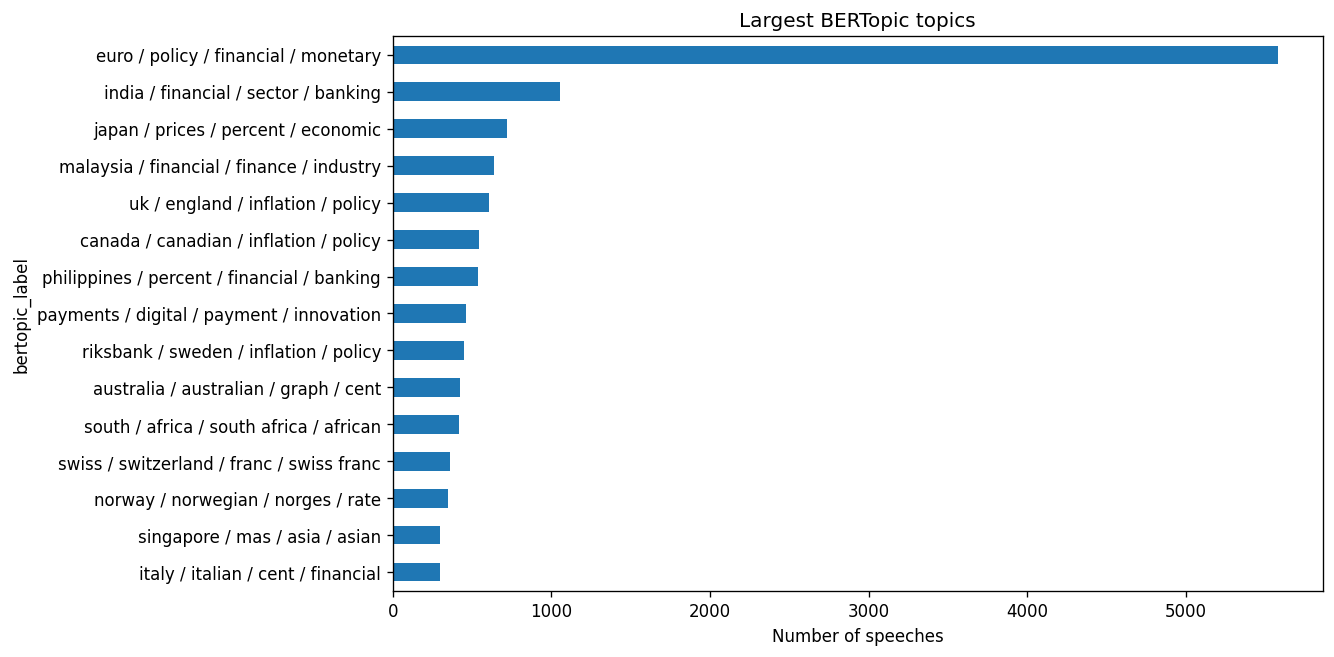

,count
bertopic_label,
euro / policy / financial / monetary,5582
india / financial / sector / banking,1053
japan / prices / percent / economic,721
malaysia / financial / finance / industry,637
uk / england / inflation / policy,607
canada / canadian / inflation / policy,546
philippines / percent / financial / banking,535
payments / digital / payment / innovation,462
riksbank / sweden / inflation / policy,450


In [15]:
non_outlier_df = df_bertopic[df_bertopic["bertopic_topic"] != -1].copy()

topic_counts = (
    non_outlier_df["bertopic_label"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10, 6))
topic_counts[::-1].plot(kind="barh")
plt.xlabel("Number of speeches")
plt.title("Largest BERTopic topics")
plt.show()

topic_counts

## 15. Topic prevalence over time

We compute the yearly share of the main topics.

This gives a temporal interpretation comparable to the NMF and LDA analyses.


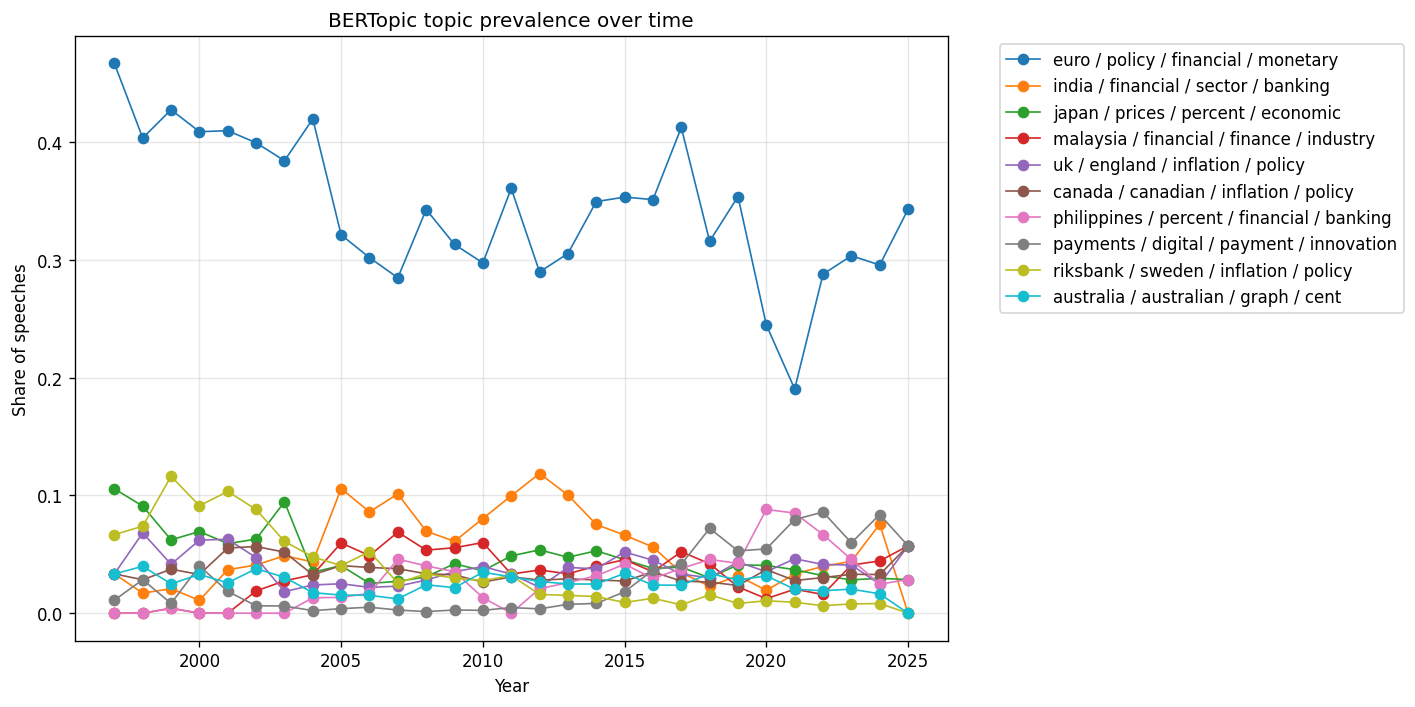

In [16]:
top_labels = topic_counts.head(10).index.tolist()

year_topic_share = pd.crosstab(
    non_outlier_df["year"],
    non_outlier_df["bertopic_label"],
    normalize="index"
)

year_topic_share_top = year_topic_share[top_labels]

plt.figure(figsize=(12, 6))

for label in top_labels:
    plt.plot(
        year_topic_share_top.index,
        year_topic_share_top[label],
        marker="o",
        linewidth=1,
        label=label
    )

plt.xlabel("Year")
plt.ylabel("Share of speeches")
plt.title("BERTopic topic prevalence over time")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 16. Topic prevalence by macro-financial period

This aggregates BERTopic topics across the macro-financial periods defined during the EDA.

The interpretation should focus on broad changes rather than small numerical differences.


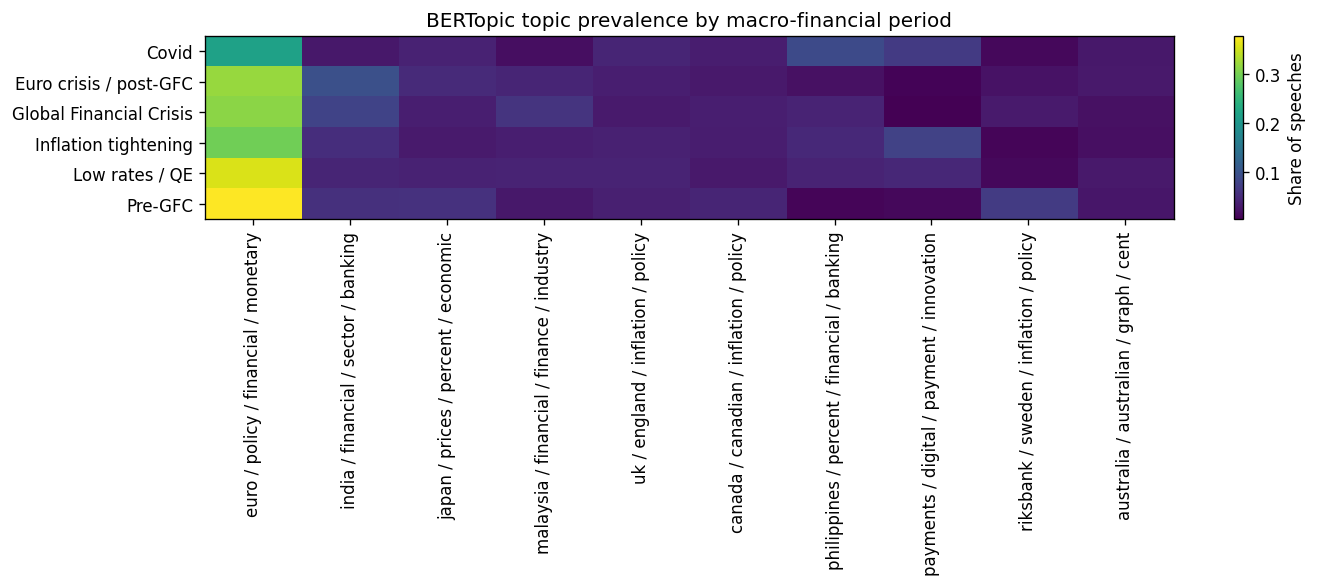

bertopic_label,euro / policy / financial / monetary,india / financial / sector / banking,japan / prices / percent / economic,malaysia / financial / finance / industry,uk / england / inflation / policy,canada / canadian / inflation / policy,philippines / percent / financial / banking,payments / digital / payment / innovation,riksbank / sweden / inflation / policy,australia / australian / graph / cent
macro_period,,,,,,,,,,
Covid,0.218215,0.026150,0.038774,0.016231,0.040577,0.032462,0.086564,0.066727,0.009919,0.026150
Euro crisis / post-GFC,0.320459,0.094803,0.047753,0.040496,0.034410,0.028558,0.018493,0.005384,0.020833,0.028324
Global Financial Crisis,0.313567,0.077269,0.033243,0.059299,0.028751,0.034591,0.040431,0.002246,0.029650,0.019317
Inflation tightening,0.296490,0.051860,0.029859,0.034049,0.036145,0.032478,0.045574,0.075956,0.007334,0.018334
Low rates / QE,0.357606,0.041397,0.038653,0.039401,0.040399,0.027681,0.039651,0.044888,0.010474,0.028678
Pre-GFC,0.378756,0.054151,0.055936,0.027075,0.035704,0.041059,0.007141,0.010414,0.067837,0.024398


In [17]:
period_topic_share = pd.crosstab(
    non_outlier_df["macro_period"],
    non_outlier_df["bertopic_label"],
    normalize="index"
)

period_topic_share_top = period_topic_share[top_labels]

plt.figure(figsize=(12, 5))
plt.imshow(period_topic_share_top, aspect="auto")
plt.colorbar(label="Share of speeches")
plt.xticks(
    ticks=np.arange(len(period_topic_share_top.columns)),
    labels=period_topic_share_top.columns,
    rotation=90
)
plt.yticks(
    ticks=np.arange(len(period_topic_share_top.index)),
    labels=period_topic_share_top.index
)
plt.title("BERTopic topic prevalence by macro-financial period")
plt.tight_layout()
plt.show()

period_topic_share_top

## 17. Optional robustness check: alternative minimum topic size

This optional section tests whether BERTopic is too sensitive to the HDBSCAN `min_cluster_size`.

To save time, it is disabled by default.  
If you have enough time, set `RUN_ROBUSTNESS = True`.

This is not required for the main project, but it is useful if you want to mention a small robustness check in the report.


In [18]:
RUN_ROBUSTNESS = False

if RUN_ROBUSTNESS:
    robustness_results = []

    for min_size in [50, 100, 200]:
        print("=" * 100)
        print(f"Testing min_cluster_size = {min_size}")

        hdbscan_tmp = HDBSCAN(
            min_cluster_size=min_size,
            min_samples=10,
            metric="euclidean",
            cluster_selection_method="eom",
            prediction_data=True
        )

        model_tmp = BERTopic(
            embedding_model=embedding_model,
            umap_model=umap_model,
            hdbscan_model=hdbscan_tmp,
            vectorizer_model=vectorizer_model,
            language="english",
            calculate_probabilities=False,
            verbose=False
        )

        topics_tmp, _ = model_tmp.fit_transform(docs, embeddings)
        info_tmp = model_tmp.get_topic_info()

        n_topics = (info_tmp["Topic"] != -1).sum()
        outlier_share = np.mean(np.array(topics_tmp) == -1)
        diversity = bertopic_topic_diversity(model_tmp, info_tmp, top_n=10)

        robustness_results.append({
            "min_cluster_size": min_size,
            "n_topics": n_topics,
            "outlier_share": outlier_share,
            "topic_diversity_top10": diversity
        })

    robustness_df = pd.DataFrame(robustness_results)
    display(robustness_df)
else:
    print("Robustness check skipped. Set RUN_ROBUSTNESS = True to run it.")

Robustness check skipped. Set RUN_ROBUSTNESS = True to run it.


## 18. Export BERTopic results

The file `bis_speeches_bertopic_results.csv` contains the original metadata plus the BERTopic topic assignment and topic label.

You can download it and use it for the report or additional analysis.


In [19]:
output_results = "bis_speeches_bertopic_results.csv"
output_topics = "bertopic_topic_info.csv"

df_bertopic.to_csv(output_results, index=False)
topic_info.to_csv(output_topics, index=False)

print("Saved:", output_results)
print("Saved:", output_topics)

files.download(output_results)
files.download(output_topics)

Saved: bis_speeches_bertopic_results.csv
Saved: bertopic_topic_info.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 19. Conclusion of this notebook

This notebook estimates BERTopic as an embedding-based topic model for BIS central bank speeches.

Compared with NMF and LDA:

- NMF and LDA rely on sparse bag-of-words representations.
- BERTopic uses dense semantic embeddings and clusters speeches in embedding space.
- BERTopic can therefore capture semantic similarity beyond exact word overlap.

The model is evaluated using:

1. number of topics,
2. outlier share,
3. topic diversity,
4. topic coherence,
5. representative speeches,
6. temporal and macro-period topic prevalence.

In the final report, BERTopic should be presented as a modern robustness extension rather than replacing the classical NMF and LDA models. The key question is whether it confirms the main themes found by the classical models and whether it adds useful semantic structure.
